In [70]:
# install the packages we'll need
!pip install pybaseball pandas matplotlib seaborn

from pybaseball import batting_stats, cache
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# turn on caching so it doesn't reload data every time
cache.enable()
sns.set(style="whitegrid")

In [72]:
# 1. get batting data for a few seasons
# grabbing 2023–2025 so we can look at some multi-year averages
bat = batting_stats(2023, 2025)
print(f"Raw data shape: {bat.shape}")

# keep only the columns that are actually useful for hitting analysis
cols = ['Season','Name','Team','Age','OPS','wOBA','SLG','HR','Barrel%','HardHit%','WAR']
bat = bat[[c for c in cols if c in bat.columns]].dropna()
print(f"After filtering columns: {bat.shape}")

Raw data shape: (408, 320)
After filtering columns: (408, 11)


Player level analysis

In [73]:
# 2. average by player (combine seasons)
# some players show up in multiple years; take their numeric average
player_stats = bat.groupby("Name", as_index=False).mean(numeric_only=True)

# make column names cleaner
player_stats = player_stats.rename(columns=lambda x: x.strip().lower().replace('%','_pct'))

print("Player-level dataset sample:")
player_stats.head()

Player-level dataset sample:


,name,season,age,ops,woba,slg,hr,barrel_pct,hardhit_pct,war
0,Aaron Judge,2024.5,32.5,1.151500,0.4695,0.6945,55.500000,0.258,0.5965,10.700000
1,Addison Barger,2025.0,25.0,0.756000,0.3220,0.4540,21.000000,0.114,0.5090,2.200000
2,Adley Rutschman,2023.5,25.5,0.759000,0.3305,0.4130,19.500000,0.068,0.3760,4.100000
3,Adolis Garcia,2024.0,31.0,0.728333,0.3120,0.4340,27.666667,0.133,0.4810,1.766667
4,Agustin Ramirez,2025.0,23.0,0.701000,0.3020,0.4130,21.000000,0.110,0.4700,0.000000


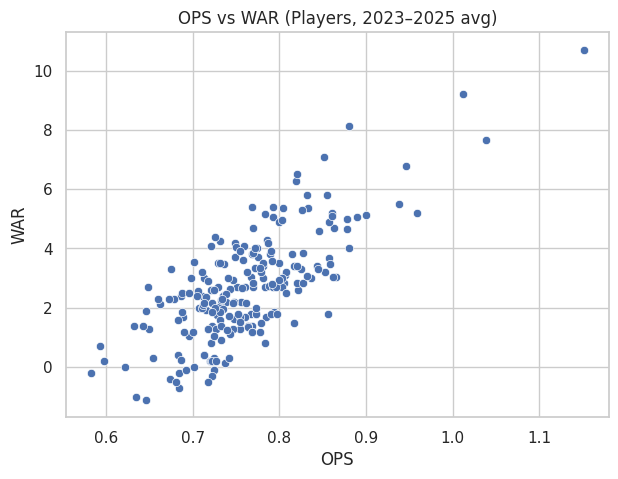

In [74]:
# 3. look at how player hitting relates to WAR
# OPS vs WAR — does hitting better actually mean more overall value?
plt.figure(figsize=(7,5))
sns.scatterplot(data=player_stats, x="ops", y="war")
plt.title("OPS vs WAR (Players, 2023–2025 avg)")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.show()


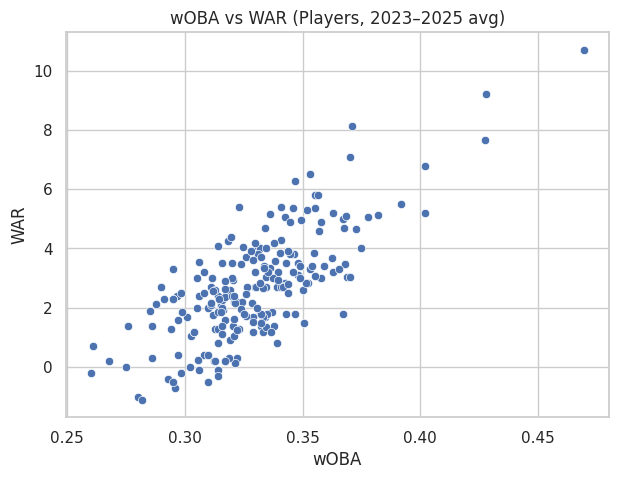

In [75]:
# wOBA vs WAR — another version of offensive value
plt.figure(figsize=(7,5))
sns.scatterplot(data=player_stats, x="woba", y="war")
plt.title("wOBA vs WAR (Players, 2023–2025 avg)")
plt.xlabel("wOBA")
plt.ylabel("WAR")
plt.show()

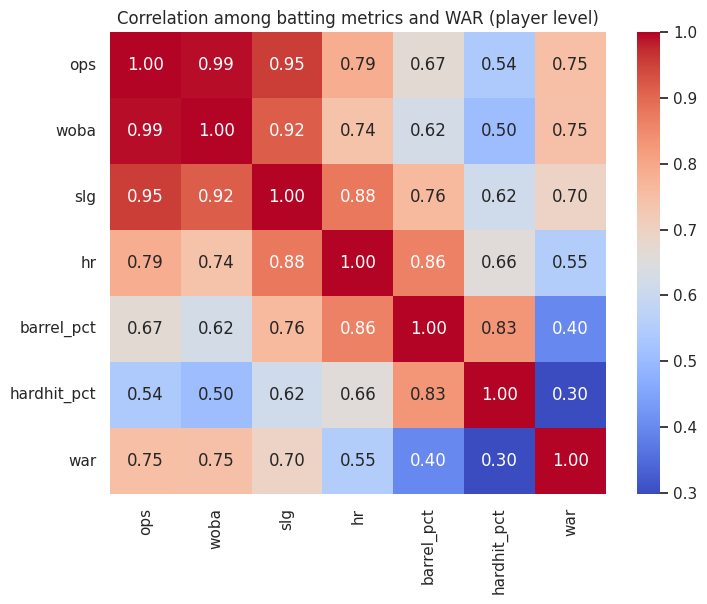

In [76]:
# check how the main hitting metrics move together
corr = player_stats[['ops','woba','slg','hr','barrel_pct','hardhit_pct','war']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation among batting metrics and WAR (player level)")
plt.show()

team-level analysis

In [77]:
# 4. average by team (to see team-wide hitting trends)
# group all players by team and take mean values
team_stats = bat.groupby("Team", as_index=False).mean(numeric_only=True)
team_stats = team_stats.rename(columns=lambda x: x.strip().lower().replace('%','_pct'))

# create a "fake" win percentage just based on OPS strength
team_stats['fake_win_pct'] = team_stats['ops'] / team_stats['ops'].max()

print("Team-level dataset sample:")
team_stats.head()

Team-level dataset sample:


,team,season,age,ops,woba,slg,hr,barrel_pct,hardhit_pct,war,fake_win_pct
0,- - -,2024.000000,29.833333,0.732767,0.319333,0.409067,18.466667,0.079267,0.402200,1.363333,0.856169
1,ARI,2024.000000,28.538462,0.821769,0.351000,0.480692,25.923077,0.098154,0.432231,4.161538,0.960160
2,ATH,2025.000000,25.400000,0.801000,0.345000,0.467400,24.000000,0.095000,0.416400,3.040000,0.935893
3,ATL,2023.733333,28.533333,0.814600,0.348133,0.476600,28.800000,0.113067,0.455200,3.513333,0.951784
4,BAL,2023.818182,25.090909,0.780273,0.335727,0.450091,23.909091,0.096091,0.445273,3.672727,0.911676


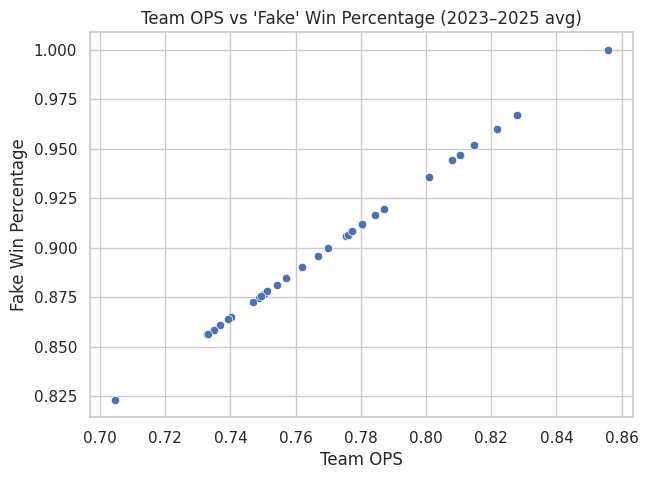

In [78]:
# 5. see if team hitting connects to success (fake win%)
# -------------------------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(data=team_stats, x="ops", y="fake_win_pct")
plt.title("Team OPS vs 'Fake' Win Percentage (2023–2025 avg)")
plt.xlabel("Team OPS")
plt.ylabel("Fake Win Percentage")
plt.show()

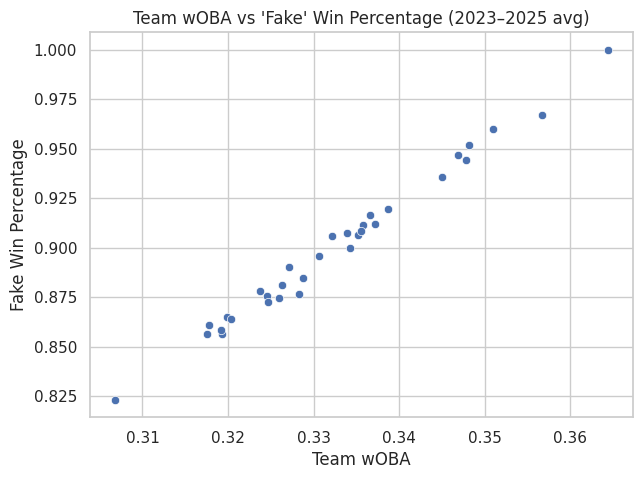

In [79]:
# try with wOBA too
plt.figure(figsize=(7,5))
sns.scatterplot(data=team_stats, x="woba", y="fake_win_pct")
plt.title("Team wOBA vs 'Fake' Win Percentage (2023–2025 avg)")
plt.xlabel("Team wOBA")
plt.ylabel("Fake Win Percentage")
plt.show()

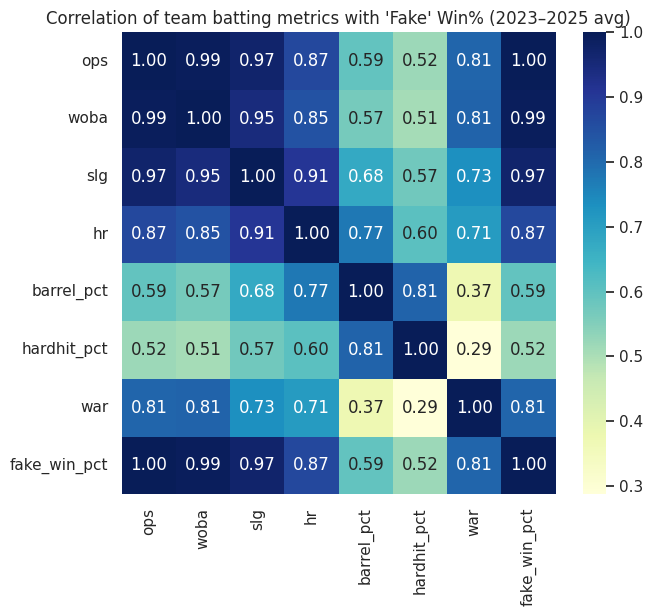

In [81]:
# check which hitting stats line up best with this fake win%
team_corr = team_stats[['ops','woba','slg','hr','barrel_pct','hardhit_pct','war','fake_win_pct']].corr()
plt.figure(figsize=(7,6))
sns.heatmap(team_corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation of team batting metrics with 'Fake' Win% (2023–2025 avg)")
plt.show()

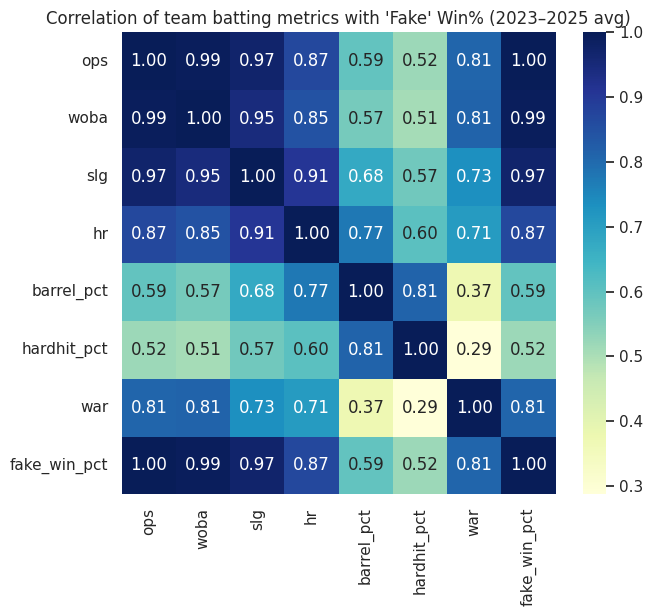

In [82]:
# check which hitting stats line up best with this fake win%
team_corr = team_stats[['ops','woba','slg','hr','barrel_pct','hardhit_pct','war','fake_win_pct']].corr()
plt.figure(figsize=(7,6))
sns.heatmap(team_corr, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation of team batting metrics with 'Fake' Win% (2023–2025 avg)")
plt.show()

In [84]:
# 6. a quick summary
corr_ops_war = player_stats['ops'].corr(player_stats['war'])
corr_woba_war = player_stats['woba'].corr(player_stats['war'])
corr_ops_fake = team_stats['ops'].corr(team_stats['fake_win_pct'])
corr_woba_fake = team_stats['woba'].corr(team_stats['fake_win_pct'])

print("Top 5 hitters by WAR (multi-season average):")
display(player_stats[['name','war']].sort_values('war', ascending=False).head())

print(f"Correlation between OPS and WAR: {corr_ops_war:.3f}")
print(f"Correlation between wOBA and WAR: {corr_woba_war:.3f}")
print(f"Correlation between OPS and Fake Win%: {corr_ops_fake:.3f}")
print(f"Correlation between wOBA and Fake Win%: {corr_woba_fake:.3f}")


Top 5 hitters by WAR (multi-season average):


,name,war
0,Aaron Judge,10.700000
176,Ronald Acuna Jr.,9.200000
22,Bobby Witt Jr.,8.133333
184,Shohei Ohtani,7.666667
70,Geraldo Perdomo,7.100000


Correlation between OPS and WAR: 0.748
Correlation between wOBA and WAR: 0.746
Correlation between OPS and Fake Win%: 1.000
Correlation between wOBA and Fake Win%: 0.994
